In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf


In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset
magic_gamma_telescope = fetch_ucirepo(id=159)

# Features and target
X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

cols = ["fLength", "fWidth", "fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"];
df = X.copy()
df["class"] = y

df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [4]:
df["class"] = (df["class"] == "g").astype(int)

In [ ]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


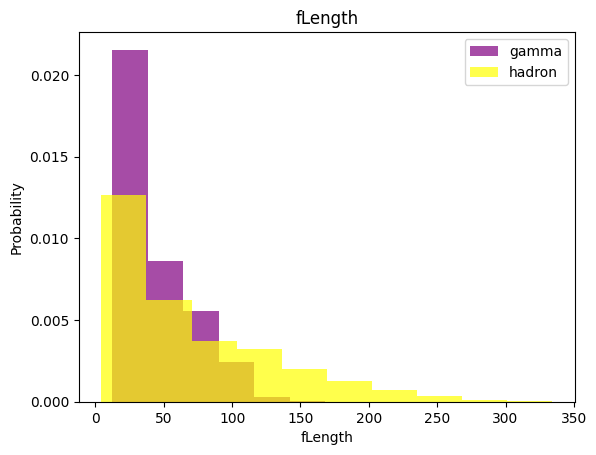

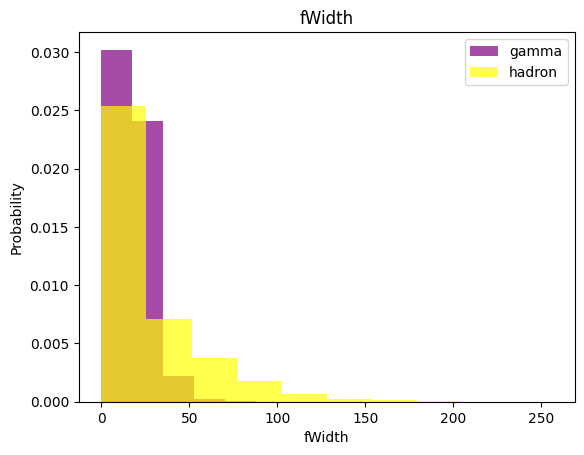

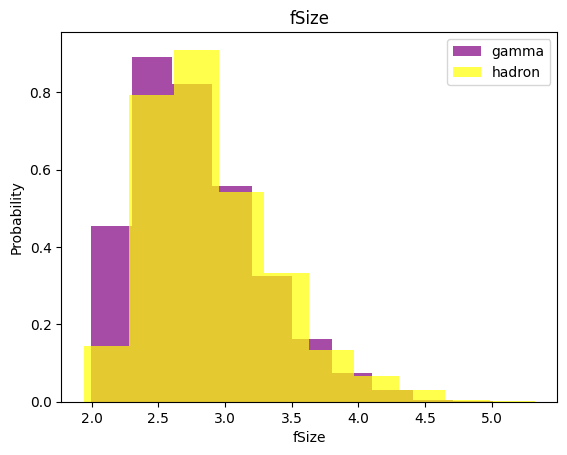

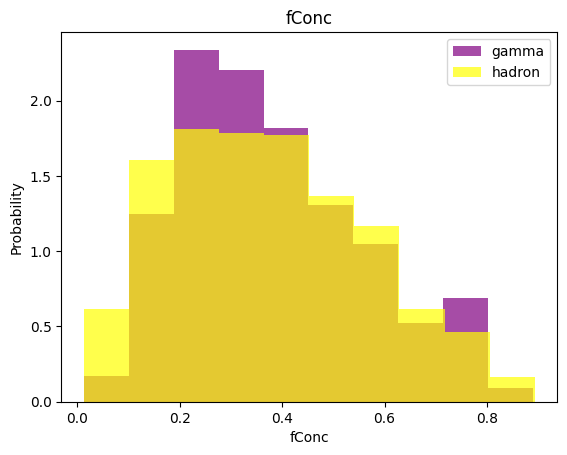

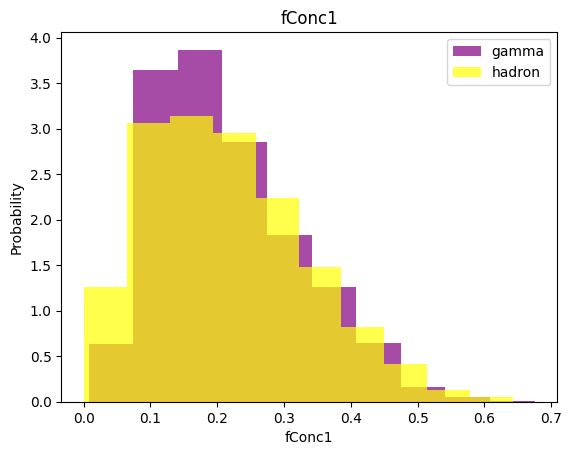

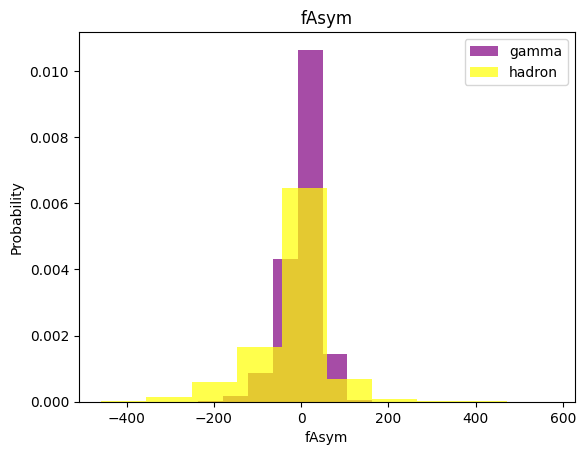

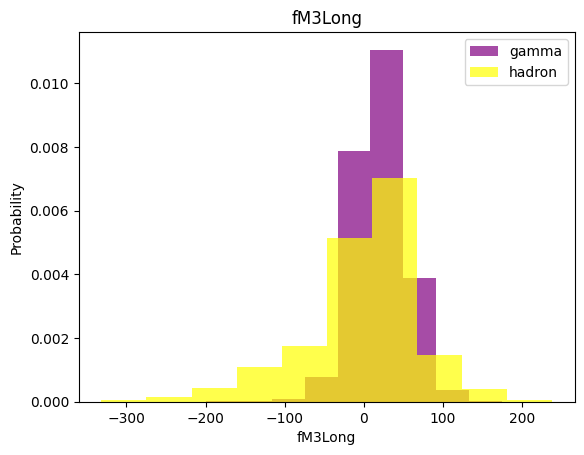

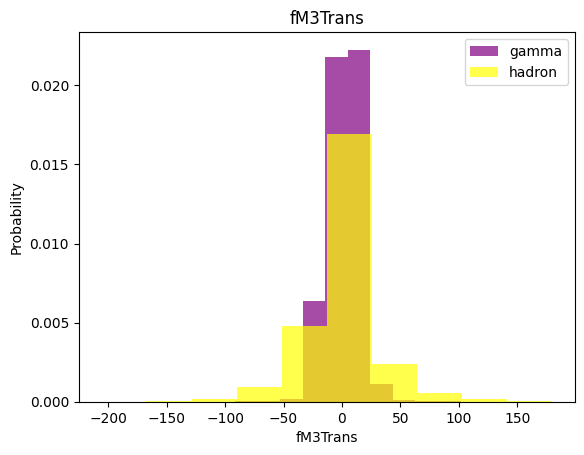

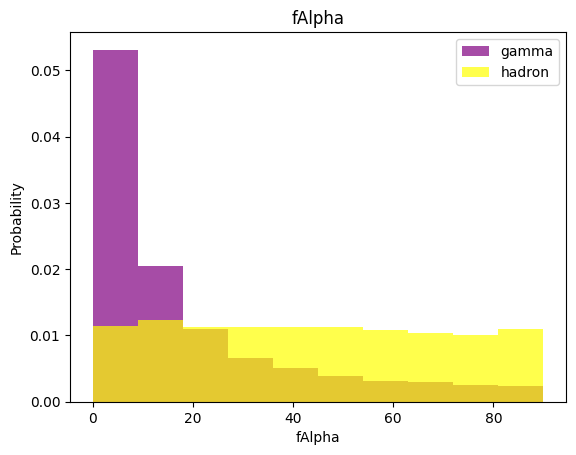

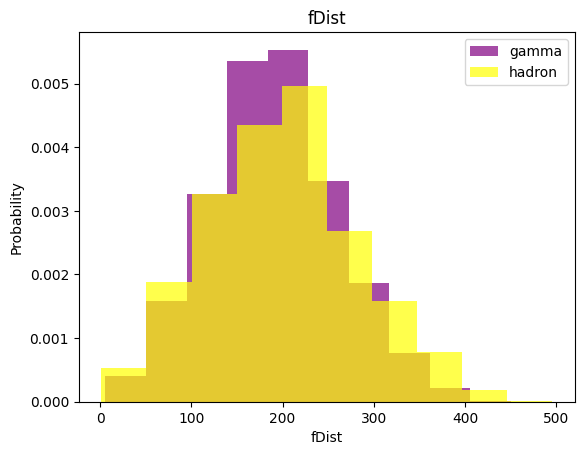

In [6]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color="purple", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][label], color="yellow", label="hadron",alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [7]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [8]:
train

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
18105,31.1424,9.3064,2.6739,0.4767,0.2786,-3.7894,21.0948,-4.2359,53.9669,55.5175,0
4104,37.5611,17.6858,2.7308,0.2677,0.1348,21.3794,27.5768,-7.7317,19.7833,202.7540,1
4366,94.7947,30.5758,3.2155,0.1802,0.0953,6.2878,-31.1087,-17.1446,0.4788,335.3990,1
18724,41.1473,14.5533,2.8178,0.2374,0.1028,30.4315,-10.3292,-4.1153,82.2647,147.1082,0
6597,57.0377,18.2816,3.3557,0.2217,0.1126,44.0953,40.1071,-8.7296,2.3590,226.3380,1
...,...,...,...,...,...,...,...,...,...,...,...
14111,46.3787,16.4464,2.7868,0.4363,0.2655,-64.9737,29.6298,10.8650,25.8040,280.1000,0
2857,33.5280,21.3633,3.0671,0.2554,0.1290,-25.1954,16.0213,-10.2241,2.3111,171.2340,1
8147,52.4962,25.9855,3.2056,0.2068,0.1124,39.4791,31.1899,-11.3310,8.9195,246.5890,1
11167,70.3003,25.9827,3.7191,0.1950,0.1112,45.7945,76.1355,17.9328,0.5190,262.1250,1


In [ ]:
print(len(train[train["class"]==1])) # gamma
print(len(train[train["class"]==0])) # hadron

7388
4024


In [10]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe[cols[:-1]].values
    y = dataframe[cols[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1,1))))

    return data, X, y


In [11]:
train, X_train, y_train = scale_dataset(train, oversample=True)

In [ ]:
len(y_train)

14776

In [ ]:
sum(y_train==1)  # gamma

np.int64(7388)

In [14]:
sum(y_train==0)  # hadron

np.int64(7388)

In [15]:
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

**Neural Networks**


In [16]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_ylabel('Binarycrossentropy')
    ax1.set_xlabel('Epoch')
    ax1.grid(True)

    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.grid(True)
    
    plt.show()


In [17]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes,  activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    history = nn_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
    )
    return nn_model, history

In [18]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 50
for num_nodes in [32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.001, 0.005]:
            for batch_size in [32, 64]:

                print(
                    f"{num_nodes} nodes, "
                    f"dropout {dropout_prob}, "
                    f"lr {lr}, "
                    f"batch size {batch_size}"
                )

                model, history = train_model(
                    X_train,
                    y_train,
                    num_nodes,
                    dropout_prob,
                    lr,
                    batch_size,
                    epochs
                )

                val_loss, val_accuracy = model.evaluate(
                    X_valid,
                    y_valid,
                    verbose=0
                )

                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model

32 nodes, dropout 0, lr 0.001, batch size 32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7759 - loss: 0.4580 - val_accuracy: 0.7023 - val_loss: 0.5463
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8335 - loss: 0.3786 - val_accuracy: 0.6965 - val_loss: 0.5540
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8508 - loss: 0.3533 - val_accuracy: 0.7196 - val_loss: 0.5280
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8582 - loss: 0.3407 - val_accuracy: 0.7486 - val_loss: 0.4856
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8602 - loss: 0.3330 - val_accuracy: 0.7713 - val_loss: 0.4618
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8631 - loss: 0.3287 - val_accuracy: 0.7727 - val_loss: 0.4600
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.3248 - val_accuracy: 0.7399 - val_loss: 0.4917
Epoch 8/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8673 - loss: 0.3205 - val_accuracy: 0.

In [22]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)
print(y_pred)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0 1 0 ... 0 1 1]


In [23]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [24]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1332
           1       0.88      0.94      0.91      2472

    accuracy                           0.88      3804
   macro avg       0.88      0.85      0.86      3804
weighted avg       0.88      0.88      0.88      3804



In [25]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.8780



In [26]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1008  324]
 [ 140 2332]]


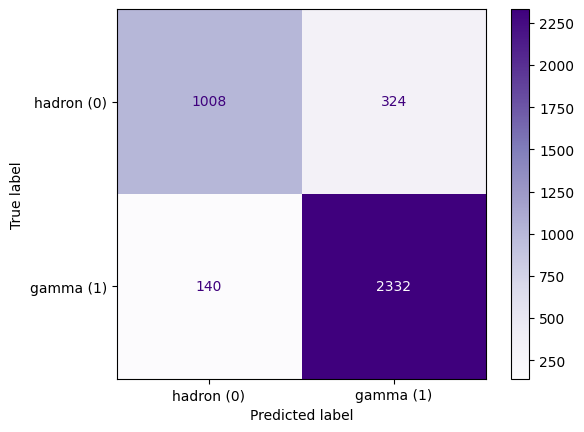

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["hadron (0)", "gamma (1)"])
disp.plot(cmap="Purples") 
plt.show()